In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from math import gcd
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve

In [2]:
data = pd.read_csv('clean.csv')

Dataset loaded: 11000 rows, 20 columns
Features (X): 18 columns
Target (y) distribution:
Has_Anxiety
0    2795
1    8205
Name: count, dtype: int64

Class balance ratio (%):
Has_Anxiety
0    25.41
1    74.59
Name: count, dtype: float64

Class balance ratio: 559:1641 (No Anxiety : Anxiety)


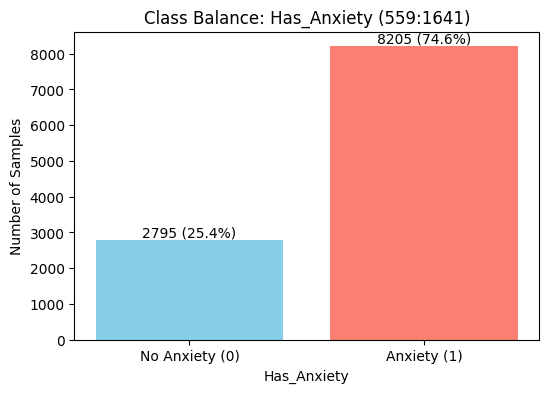

In [3]:
# Binary target
data["Has_Anxiety"] = (data["Anxiety Level (1-10)"] >= 3).astype(int)
X = data.drop(["Anxiety Level (1-10)", "Has_Anxiety"], axis=1)
y = data["Has_Anxiety"]

# Counts sorted by class label
counts = y.value_counts().sort_index()  # ensures 0, 1 order

# Class balance ratio (percentage)
class_ratio = counts / counts.sum()

# Simplified ratio
g = gcd(counts[0], counts[1])
ratio_str = f"{counts[0]//g}:{counts[1]//g}"

# Print info
print(f"Dataset loaded: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Features (X): {X.shape[1]} columns")
print(f"Target (y) distribution:\n{counts}")
print("\nClass balance ratio (%):")
print((class_ratio * 100).round(2))
print(f"\nClass balance ratio: {ratio_str} (No Anxiety : Anxiety)")

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(counts.index.astype(str), counts.values, color=['skyblue', 'salmon'])
plt.title(f"Class Balance: Has_Anxiety ({ratio_str})")
plt.xlabel("Has_Anxiety")
plt.ylabel("Number of Samples")
plt.xticks([0,1], ["No Anxiety (0)", "Anxiety (1)"])

# Add count + percentage on top
for bar, ratio in zip(bars, class_ratio):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, 
             f"{int(height)} ({ratio*100:.1f}%)", ha='center', va='bottom', fontsize=10)

plt.show()

Identify categorical and numeric columns

In [4]:

# 4. Identifying categorical and numeric columns
# --------------------------
cat_cols = ['Gender', 'Occupation']  
num_cols = [c for c in X.columns if c not in cat_cols]  


ONEHOTENCODING AND FEASURE SCALING

In [5]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

LOGISTIC REGRESSION MODEL WITH CLASS WEIGHT BALANCED LOSS

In [6]:

model = Pipeline([
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])


SPLITTING THE DATASET INTO TEST AND TRAIN SET

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


TRAIN THE MODEL

In [8]:

model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

MODEL MAKE PREDICTIONS AND PROBABILITIES OF THE TARGET CLASS

In [9]:
y_prob = model.predict_proba(X_test)[:, 1]  
y_pred = model.predict(X_test) # my classifier is using the classification threshold of 0.5 by default         


EVALUATE THE MODEL

Accuracy : 0.7845
Precision: 0.9300
Recall   : 0.7690
F1-score : 0.8419
AUC-ROC  : 0.8748
Best threshold: 0.5699811111364689


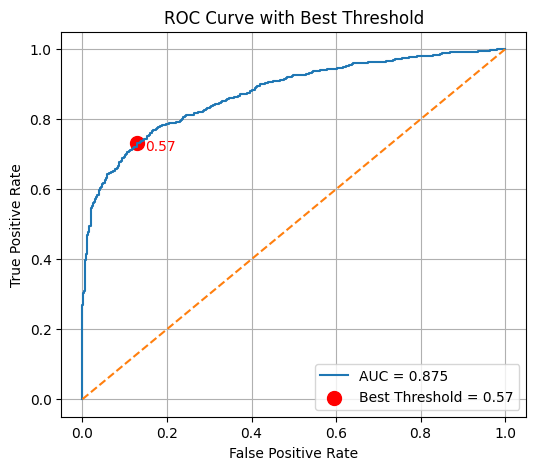

In [10]:

# Metrics at default threshold (0.5)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

# ROC curve and best threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
J = tpr - fpr
best_idx = np.argmax(J)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

# Highlight best threshold point
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', s=100, label=f"Best Threshold = {best_threshold:.2f}")
plt.text(fpr[best_idx]+0.02, tpr[best_idx]-0.02, f"{best_threshold:.2f}", color='red')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Best Threshold")
plt.legend()
plt.grid(True)
plt.show()
